# ENGSCI205 - Section A (Data Science)
## Lab 1 - scikit-learn

Welcome to your first laboratory on Data Science. The laboratory and the material provided in this notebook introduces the application programming interface (API) of scikit-learn and implements some typical regression problems using machine learning approaches.



### Prepare the data

The code of this section has been modified from `https://github.com/ageron/handson-ml2/blob/master/01_the_machine_learning_landscape.ipynb`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

In [2]:
def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

In [3]:
import os
datapath = os.path.join("data", "raw")

In [4]:
# Download the data
import urllib.request
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
os.makedirs(datapath, exist_ok=True)
for filename in ("oecd_bli_2015.csv", "gdp_per_capita.csv"):
    print("Downloading", filename)
    url = DOWNLOAD_ROOT + "datasets/lifesat/" + filename
    urllib.request.urlretrieve(url, datapath + filename)

In [5]:
# Load the data
oecd_bli = pd.read_csv(datapath + "oecd_bli_2015.csv", thousands=',')
gdp_per_capita = pd.read_csv(datapath + "gdp_per_capita.csv",thousands=',',delimiter='\t',
                             encoding='latin1', na_values="n/a")

# Prepare the data
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)

### Inspect the data
#### Show the first five rows of DataFrame `country_stats`
Tip: Use the `.head()` method provided by DataFrame objects.

DataFrame `country_stats` corresponds to the input data $\mathcal{D}$.

Rule of thumb: Always inspect the raw input data in case there are any unexpected data types.

In [6]:
country_stats.head(5)

# This cose was used to find the median GDP per capita
# median_mat = country_stats["GDP per capita"]
# median_mat.median()

,GDP per capita,Life satisfaction
Country,,
Russia,9054.914,6.0
Turkey,9437.372,5.6
Hungary,12239.894,4.9
Poland,12495.334,5.8
Slovak Republic,15991.736,6.1


#### What is the number $N$ of samples?
Tip: Use the `.shape` attribute.

country_stats.shape[0] * country_stats.shape[1]

In [7]:
N = country_stats.shape[0]

#### Create a scatter plot of _Life satisfaction_ vs _GDP per capita_
Don't forget to label the axis.

Text(0.5, 1.0, 'Life satisfaction vs GDP per capita ($)')

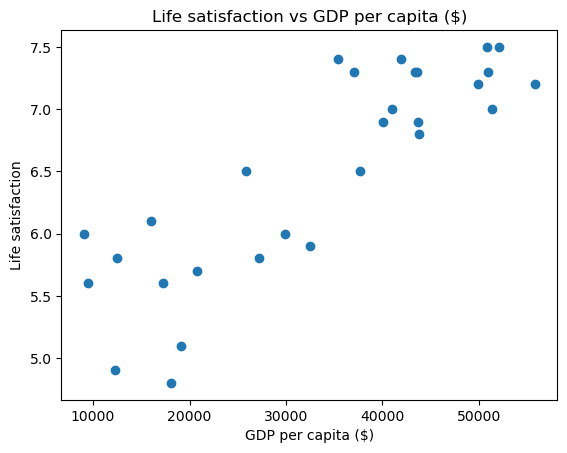

In [8]:
plt.scatter(country_stats.iloc[:, 0], country_stats.iloc[:, 1])
plt.xlabel("GDP per capita ($)")
plt.ylabel("Life satisfaction")
plt.title("Life satisfaction vs GDP per capita ($)")

#### Split the input data in feature matrix $X$ and target vector $y$

In [9]:
X = country_stats[['GDP per capita']]  # Notice this double brackets: X needs to be a matrix
y = country_stats['Life satisfaction'] # y needs to be a vector

#### What are the dimensions of $X$ and $y$?

In [10]:
X.shape, y.shape

((29, 1), (29,))

#### Fit a linear regression model

In scikit-learn, there are always three steps for fitting a regression model:

1. Import the estimator class
    
2. Create an instance of the estimator (while configuring any hyperparameters). Note, hyperparameter configuration is not necessary for simple linear regression.

3. Fit the linear regression model using the `.fit()` method.

In [11]:
from sklearn.linear_model import LinearRegression  # step 1

model = LinearRegression()                         # step 2

In [12]:
# step 3
model.fit(X, y)

LinearRegression()

#### What are the weights of the fitted model?

For simple linear regression, we wanted to fit the following model: $y = w_0 + w_1 x$

Hint: Inspect attributes `.intercept_` and `.coef_`. 

In [13]:
print("w0 is", model.intercept_)
print("w1 is", model.coef_[0])

w0 is 4.853052800266435
w1 is 4.911544589158485e-05


Note: The intercept is special, because scikit-learn automatically adds a column of ones before fitting the model.

#### Really? Use the analytical solution from lecture MI02 to compute $\hat{w}_0$ and $\hat{w}_1$.

Start with creating a design matrix $X$ as shown on slide 19 of lecture MI02. Then use `np.linalg.inv()` to compute the formula for $\hat{\vec{\theta}}$ from slide 18.

Hint: Both tasks require only one line of code each!

In [14]:
design_mat = np.concatenate((np.ones((N, 1)), X), 1)

In [15]:
theta = np.linalg.inv(np.transpose(design_mat) @ design_mat) @ np.transpose(design_mat) @ y
print("w0 is", theta[0])
print("w1 is", theta[1])

print("The difference between the analytical result and the LinearRegression estimator for w0 is", theta[0] - model.intercept_)
print("The difference between the analytical result and the LinearRegression estimator for w1 is", theta[1] - model.coef_[0])

w0 is 4.8530528002664335
w1 is 4.911544589158494e-05
The difference between the analytical result and the LinearRegression estimator for w0 is -1.7763568394002505e-15
The difference between the analytical result and the LinearRegression estimator for w1 is 8.809142651444724e-20


Compare the analytical result of $\hat{\vec{\theta}}$ with the result from fitting the `LinearRegression` estimator.

##### Plot the input data and the fitted model.
Don't forget the axis labels. Create a legend by configuring the `label` argument of the plotting commands in combination with `plt.legend()`.

Text(0.5, 1.0, 'Life satisfaction vs GDP per capita ($)')

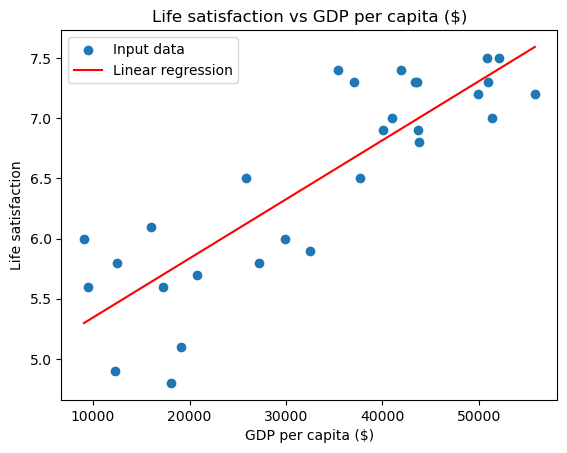

In [16]:
plt.scatter(country_stats.iloc[:, 0], country_stats.iloc[:, 1], label="Input data")
plt.plot(country_stats.iloc[:, 0], (model.intercept_ + model.coef_ * country_stats.iloc[:, 0]), label="Linear regression", color="r")
plt.legend()
plt.xlabel("GDP per capita ($)")
plt.ylabel("Life satisfaction")
plt.title("Life satisfaction vs GDP per capita ($)")

#### Fit an instance based model using `KNeighborsRegressor` and three nearest neighbors

In [17]:
# Correct the following code in order to instantiate the model with the desired
# hyperparameter (number of nearest neighbors)
import sklearn.neighbors
knr_model = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)

In [18]:
knr_model.fit(X, y)

KNeighborsRegressor(n_neighbors=3)

#### Create a plot, which compares the linear regression and the kneighbors model

Hint: Use the `.predict()` method to compute predictions.

Text(0.5, 1.0, 'Life satisfaction vs GDP per capita ($)')

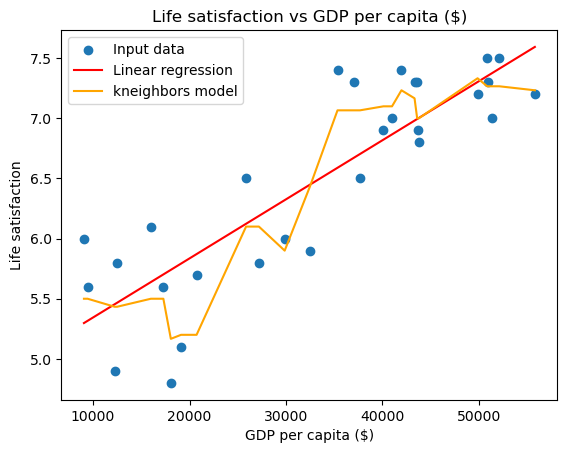

In [19]:
knr_predictions = knr_model.predict(X)

plt.scatter(country_stats.iloc[:, 0], country_stats.iloc[:, 1], label="Input data")
plt.plot(country_stats.iloc[:, 0], (model.intercept_ + model.coef_ * country_stats.iloc[:, 0]), label="Linear regression", color="r")
plt.plot(country_stats.iloc[:, 0], knr_predictions, color="orange", label="kneighbors model")
plt.legend()
plt.xlabel("GDP per capita ($)")
plt.ylabel("Life satisfaction")
plt.title("Life satisfaction vs GDP per capita ($)")

#### Which model has the better in-sample MSE performance?

In [20]:
from sklearn.metrics import mean_squared_error

In [21]:
mse_knr = mean_squared_error(y, knr_predictions)
mse_rgr = mean_squared_error(y, model.predict(X))
if mse_rgr > mse_knr:
    print("kneighbours has better in-sample MSE performance than linear regression.")
else:
    print("Linear regression has better in-sample MSE performance than kneighbours.")

kneighbours has better in-sample MSE performance than linear regression.


#### Which model generalizes better to new samples?

Hint: Compare the out-of-sample performance using `cross_val_predict`.

In [22]:
from sklearn.model_selection import cross_val_predict

In [23]:
cvp_rgr = cross_val_predict(model, X, y)
cvp_knr = cross_val_predict(knr_model, X, y)

mse_cvp_rgr = mean_squared_error(y, cvp_rgr)
mse_cvp_knr = mean_squared_error(y, cvp_knr)

if mse_cvp_rgr > mse_cvp_knr:
    print("kneighbours has better out-of-sample performance than regression and generalises better to new samples.")
else:
    print("Linear regression has better out-of-sample performance than kneighbours and generalises better to new samples.")

Linear regression has better out-of-sample performance than kneighbours and generalises better to new samples.


#### Find the optimal value for hyperparameter `n_neighbors` and visualize MSE vs n_neighbors

Hint: Systematically change `n_neighbors` between one and nine. Evaluate every model using `cross_val_predict` and `mean_squared_error`.

The optimal value for the hyperparameter 'n_neighbours' is 6 with an error of 0.17856321839080466.


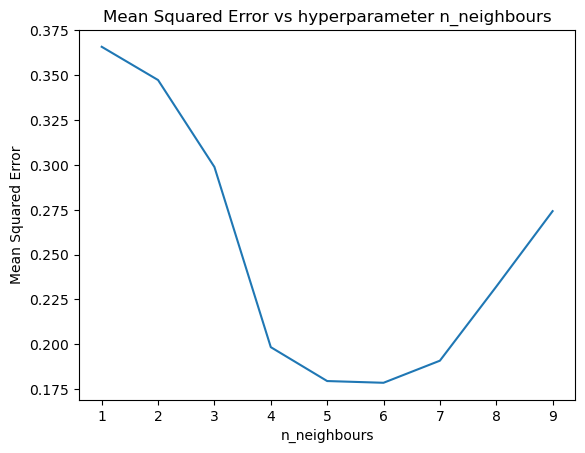

In [44]:
knr_mses = [0] * 9
index = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for i in range(9):
    knr_model = sklearn.neighbors.KNeighborsRegressor(n_neighbors = i + 1)
    knr_model.fit(X, y)
    n_knr_mse = mean_squared_error(y, cross_val_predict(knr_model, X, y))
    knr_mses[i] = n_knr_mse
    if i == 0:
        min_knr_mse = n_knr_mse
        min_mse_index = i + 1
    elif i != 0 and n_knr_mse < min_knr_mse:
        min_knr_mse = n_knr_mse
        min_mse_index = i + 1

plt.plot(index, knr_mses)
plt.title("Mean Squared Error vs hyperparameter n_neighbours")
plt.xlabel("n_neighbours")
plt.ylabel("Mean Squared Error")

print("The optimal value for the hyperparameter 'n_neighbours' is", min_mse_index, "with an error of", str(min_knr_mse) + ".")

#### Repeat the experiment using polynomial regression

In [45]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

def make_poly_reg(degree=3):
    """
    This function is a so-called `factory` (software engineering), which returns 
    a machine learning pipeline. The pipeline provides `.fit()` and `.predict()` methods
    like any other estimator.
    """
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linreg', LinearRegression())
    ])
    return model

The optimal value for the hyperparameter 'degree' is 7 with an error of 0.20363696911115134.


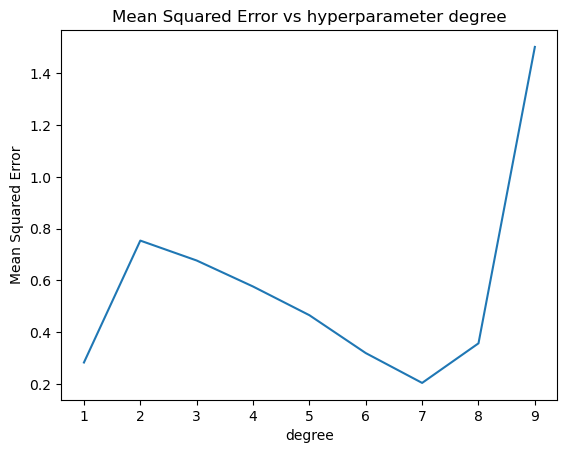

In [46]:
poly_mses = [0] * 9

for i in range(9):
    poly_model = make_poly_reg(i + 1)
    poly_model.fit(X, y)
    
    n_poly_mse = mean_squared_error(y, cross_val_predict(poly_model, X, y))
    poly_mses[i] = n_poly_mse
    if i == 0:
        min_mse = n_poly_mse
        min_mse_index = i + 1
    elif i != 0 and n_poly_mse < min_mse:
        min_mse = n_poly_mse
        min_mse_index = i + 1

plt.plot(index, poly_mses)
plt.title("Mean Squared Error vs hyperparameter degree")
plt.xlabel("degree")
plt.ylabel("Mean Squared Error")

print("The optimal value for the hyperparameter 'degree' is", min_mse_index, "with an error of", str(min_mse) + ".")

#### Create a figure, which compares the models' MSE vs their hyperparameters and identify the best model

kneighbours is the best model, as it has the lower minimum MSE.


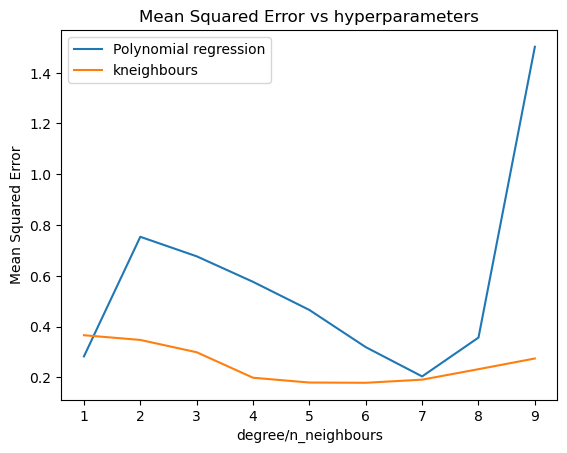

In [47]:
plt.title("Mean Squared Error vs hyperparameters")
plt.xlabel("degree/n_neighbours")
plt.ylabel("Mean Squared Error")
plt.plot(index, poly_mses, label="Polynomial regression")
plt.plot(index, knr_mses, label="kneighbours")
plt.legend()

if min(poly_mses) > min(knr_mses):
    print("kneighbours is the best model, as it has the lower MSE when optimised.")
else:
    print("Polynomial regression is the best model, as it has the lower MSE when optimised.")

#### Which model is better suited for describing the relation between feature `GDP per capita` and target `life satisfaction`?

Text(0.5, 1.0, 'Life satisfaction vs GDP per capita ($)')

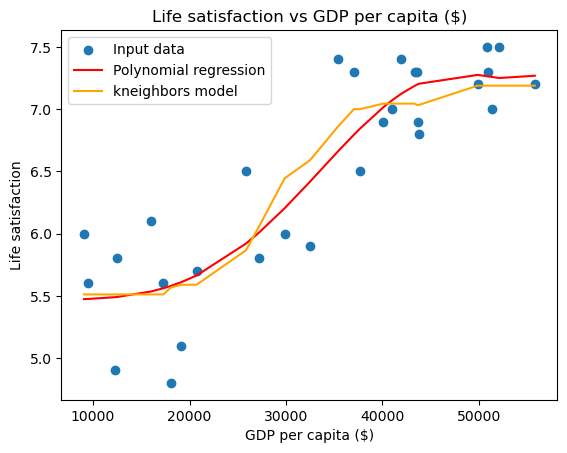

In [48]:
poly_model = make_poly_reg(7)
poly_model.fit(X, y)

knr_predictions = knr_model.predict(X)
poly_predictions = poly_model.predict(X)

plt.scatter(country_stats.iloc[:, 0], country_stats.iloc[:, 1], label="Input data")
plt.plot(country_stats.iloc[:, 0], poly_predictions, label="Polynomial regression", color="r")
plt.plot(country_stats.iloc[:, 0], knr_predictions, color="orange", label="kneighbors model")
plt.legend()
plt.xlabel("GDP per capita ($)")
plt.ylabel("Life satisfaction")
plt.title("Life satisfaction vs GDP per capita ($)")

The graph above shows that as GDP per capita increases, the value for life satisfaction also tends to increase for both models. The kneighbours model and the polynomial regression model have approximately the same trend - however, the kneighbours model is more granular, i.e., more sensitive to spread data, whereas the polynomial regression model is more smoothed out. 

For this reason, the kneighbours model is better at describing the relation between GDP per capita and life satisfaction than polynomial regression as it more precisely represents this relationship.

#### Which model is better suited for generating robust out-of-sample predictions?

The kneighbours model is better suited for generating robust out-of-sample predictions than the polynomial regression model. This is because it has a lower MSE when cross-validating (generating out-of-sample predictions), when both models have had their hyperparameters optimised.